# 99. 4분면 유형화(A/B/C/D) 종합 — 07~07_3 결과 모음

이 노트북은 새로운 분석을 수행하지 않는다. `07_medical_destination_analysis_and_insights.ipynb`,
`07_1_medical_destination_analysis_and_insights.ipynb`, `07_2_medical_destination_analysis_and_insights.ipynb`,
`07_3_medical_destination_specialty_analysis.ipynb`에서 각각 만든 **자치구/행정동 4분면 유형화**
(의료 인프라 규모 × 콜택시 수요, 중앙값 기준 A/B/C/D)를 한 곳에 모아 나란히 비교하기 위한 정리용 노트북이다.

## 이 노트북이 하는 일 / 하지 않는 일
- **한다**: 07~07_3에서 이미 저장한 산출물(CSV)을 그대로 불러와, 각 노트북에서 썼던 것과 동일한
  중앙값 기준 4분면 분류 로직을 재적용해 시각화·비교표로 모은다.
- **하지 않는다**: 새로운 데이터를 결합하거나 새로운 파생 지표를 만들지 않는다. 모든 값은
  07_1/07_2/07_3에서 이미 검증·저장된 컬럼을 그대로 사용한다.

## 사용 데이터 (전부 read-only, 07_3 최종 산출물 4종)
- `data/processed/region_gu_call_hospital_combined_07_3_진료과목추가.csv` — 구 단위, 전체콜
- `data/processed/region_gu_call_hospital_combined_medical_07_3_진료과목추가.csv` — 구 단위, 의료목적콜
- `data/processed/region_dong_call_hospital_combined_07_3_진료과목추가.csv` — 구·동 단위, 전체콜
- `data/processed/region_dong_call_hospital_combined_medical_07_3_진료과목추가.csv` — 구·동 단위, 의료목적콜

네 파일 모두 05(원본 결합) → 06(EDA) → 07(기본 상관/유형화) → 07_1(병원급·병상수 추가) →
07_2(그룹·의사수 추가) → 07_3(진료과목 추가)를 거쳐 누적된 산출물이므로, 4분면 유형화에 쓰인 모든
컬럼(의료기관_총수, 병원급_총수, 그룹1/2_의사수, 의사수_총합, 재활의학과_보유기관수/전문의수_총합 등)이
이미 다 들어있다.

## ⚠️ 해석 원칙 (프로젝트 공통, 원본 노트북과 동일)
- 모든 4분면 분류는 **중앙값(median) 기준 이분(binary)** — 평균이 아니다.
- 상관관계≠인과관계. "의료기관이 적어서 콜이 몰린다"고 단정하지 않는다.
- 구 단위(n=25)는 표본이 작아 통계적 유의성 해석에 특히 주의. 생태학적 오류(ecological fallacy) 가능성 있음.
- 아래에서 반복 확인되지만, **어떤 지표를 기준으로 삼느냐에 따라 같은 구의 유형이 바뀔 수 있다**
  — 단일 기준으로 "이 구는 취약하다"고 단정하지 않는다.

In [1]:
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: C:\Users\young\my_project\260901_call_taxi_DA


## 0. 데이터 로드 (07_3 최종 산출물 재사용, read-only)

In [2]:
gu_all = pd.read_csv(PROCESSED_DIR / "region_gu_call_hospital_combined_07_3_진료과목추가.csv", encoding="utf-8-sig")
gu_med = pd.read_csv(PROCESSED_DIR / "region_gu_call_hospital_combined_medical_07_3_진료과목추가.csv", encoding="utf-8-sig")
dong_all = pd.read_csv(PROCESSED_DIR / "region_dong_call_hospital_combined_07_3_진료과목추가.csv", encoding="utf-8-sig")
dong_med = pd.read_csv(PROCESSED_DIR / "region_dong_call_hospital_combined_medical_07_3_진료과목추가.csv", encoding="utf-8-sig")

gu_all = gu_all.rename(columns={"콜택시_목적지_건수": "콜건수"})
gu_med = gu_med.rename(columns={"콜택시_의료목적지_건수": "콜건수"})
dong_all = dong_all.rename(columns={"콜택시_목적지_건수": "콜건수"})
dong_med = dong_med.rename(columns={"콜택시_의료목적지_건수": "콜건수"})

# 이번 노트북에서 실제로 쓰는 컬럼만 결측치 확인 (사용 전 결측 확인 원칙)
USED_COLS = [
    "콜건수", "의료기관_총수", "병원급_총수(의원/한의원제외)", "의사수_총합",
    "그룹1_의사수", "그룹2_의사수",
    "재활의학과_보유기관수_5종모집단", "재활의학과_전문의수_총합_5종모집단",
]
for name, df in [("gu_all", gu_all), ("gu_med", gu_med), ("dong_all", dong_all), ("dong_med", dong_med)]:
    present_cols = [c for c in USED_COLS if c in df.columns]
    missing = df[present_cols].isnull().sum()
    print(f"{name}: {df.shape}, 결측치(사용 컬럼 중) = {int(missing.sum())}건")

print()
print(f"gu_all 25개 구 확인: {gu_all.shape[0] == 25}, gu_med 25개 구 확인: {gu_med.shape[0] == 25}")
print(f"dong_all 431개 동 확인: {dong_all.shape[0] == 431}, dong_med 416개 동 확인: {dong_med.shape[0] == 416}")

gu_all: (25, 51), 결측치(사용 컬럼 중) = 0건
gu_med: (25, 53), 결측치(사용 컬럼 중) = 0건
dong_all: (431, 62), 결측치(사용 컬럼 중) = 0건
dong_med: (416, 62), 결측치(사용 컬럼 중) = 0건

gu_all 25개 구 확인: True, gu_med 25개 구 확인: True
dong_all 431개 동 확인: True, dong_med 416개 동 확인: True


## 1. 4분면 분류 함수 — 07~07_3에서 반복 사용한 로직 그대로 재사용

X축(규모 지표)·Y축(콜 건수) 각각을 중앙값 기준으로 이분한 뒤 조합한다.
- A(규모多+콜多) · B(규모多+콜少) · C(규모少+콜多) · D(규모少+콜少)

In [3]:
def classify_quadrant(df, xcol, ycol="콜건수"):
    med_x = df[xcol].median()
    med_y = df[ycol].median()

    def _classify(row):
        if row[xcol] >= med_x and row[ycol] >= med_y:
            return "A"
        if row[xcol] >= med_x and row[ycol] < med_y:
            return "B"
        if row[xcol] < med_x and row[ycol] >= med_y:
            return "C"
        return "D"

    out = df.copy()
    out["유형"] = out.apply(_classify, axis=1)
    return out, med_x, med_y

## 2. 지금까지 만든 4분면 유형화 전체 목록 (구 단위 9개 + 동 단위 1개)

| # | 출처 | 지역단위 | X축(규모 지표) | Y축(콜 종류) |
|---|---|---|---|---|
| 1 | 07 | 동(431개) | 의료기관_총수 | 전체콜 |
| 2 | 07_1 기준1 | 구(25개) | 의료기관_총수 | 전체콜 |
| 3 | 07_1 기준4 | 구(25개) | 의료기관_총수 | 의료목적콜 |
| 4 | 07_1 기준2 | 구(25개) | 병원급_총수(의원/한의원제외) | 의료목적콜 |
| 5 | 07_1 기준3 | 구(25개) | 병원급_총수(의원/한의원제외) | 전체콜 |
| 6 | 07_2 | 구(25개) | 의사수_총합 | 의료목적콜 |
| 7 | 07_2 그룹1 | 구(25개) | 그룹1_의사수(정신·보건계열) | 의료목적콜 |
| 8 | 07_2 그룹2 | 구(25개) | 그룹2_의사수(병원급 의료기관) | 의료목적콜 |
| 9 | 07_3 | 구(25개) | 재활의학과_보유기관수_5종모집단 | 의료목적콜 |
| 10 | 07_3 보충 | 구(25개) | 재활의학과_전문의수_총합_5종모집단 | 의료목적콜 |

In [4]:
SCHEMES = [
    {"id": "07_동_의료총수x전체콜", "source": "07", "region": "동", "df": dong_all,
     "xcol": "의료기관_총수", "x_label": "의료기관 총수", "y_label": "콜 건수(전체콜)"},
    {"id": "07_1_기준1_구_의료총수x전체콜", "source": "07_1 기준1", "region": "구", "df": gu_all,
     "xcol": "의료기관_총수", "x_label": "의료기관 총수", "y_label": "콜 건수(전체콜)"},
    {"id": "07_1_기준4_구_의료총수x의료목적콜", "source": "07_1 기준4", "region": "구", "df": gu_med,
     "xcol": "의료기관_총수", "x_label": "의료기관 총수", "y_label": "콜 건수(의료목적콜)"},
    {"id": "07_1_기준2_구_병원급x의료목적콜", "source": "07_1 기준2", "region": "구", "df": gu_med,
     "xcol": "병원급_총수(의원/한의원제외)", "x_label": "병원급 총수(의원·한의원 제외)", "y_label": "콜 건수(의료목적콜)"},
    {"id": "07_1_기준3_구_병원급x전체콜", "source": "07_1 기준3", "region": "구", "df": gu_all,
     "xcol": "병원급_총수(의원/한의원제외)", "x_label": "병원급 총수(의원·한의원 제외)", "y_label": "콜 건수(전체콜)"},
    {"id": "07_2_구_의사수x의료목적콜", "source": "07_2", "region": "구", "df": gu_med,
     "xcol": "의사수_총합", "x_label": "의사수 총합(7종_의원제외)", "y_label": "콜 건수(의료목적콜)"},
    {"id": "07_2_그룹1_구_의사수x의료목적콜", "source": "07_2 그룹1", "region": "구", "df": gu_med,
     "xcol": "그룹1_의사수", "x_label": "그룹1(정신·보건계열) 의사수", "y_label": "콜 건수(의료목적콜)"},
    {"id": "07_2_그룹2_구_의사수x의료목적콜", "source": "07_2 그룹2", "region": "구", "df": gu_med,
     "xcol": "그룹2_의사수", "x_label": "그룹2(병원급 의료기관) 의사수", "y_label": "콜 건수(의료목적콜)"},
    {"id": "07_3_구_재활보유기관수x의료목적콜", "source": "07_3", "region": "구", "df": gu_med,
     "xcol": "재활의학과_보유기관수_5종모집단", "x_label": "재활의학과 보유기관수", "y_label": "콜 건수(의료목적콜)"},
    {"id": "07_3_보충_구_재활전문의수x의료목적콜", "source": "07_3 보충", "region": "구", "df": gu_med,
     "xcol": "재활의학과_전문의수_총합_5종모집단", "x_label": "재활의학과 전문의수 합계", "y_label": "콜 건수(의료목적콜)"},
]

for s in SCHEMES:
    classified, med_x, med_y = classify_quadrant(s["df"], s["xcol"])
    s["classified"] = classified
    s["med_x"] = med_x
    s["med_y"] = med_y

print(f"총 {len(SCHEMES)}개 기준 정의 완료 (동 단위 1개 + 구 단위 9개)")

총 10개 기준 정의 완료 (동 단위 1개 + 구 단위 9개)


## 3. 기준별 4분면 한눈에 보기 (10개)

색상: A(규모多+콜多)=초록, B(규모多+콜少)=주황, C(규모少+콜多)=빨강, D(규모少+콜少)=회색.
각 패널 제목에 [출처]와 유형별 개수를 함께 표기한다. (개별 지역 라벨·상세 해석은 각 원본 노트북 참고
— 이 그리드는 전체 패턴을 한 화면에서 비교하기 위한 것이다.)

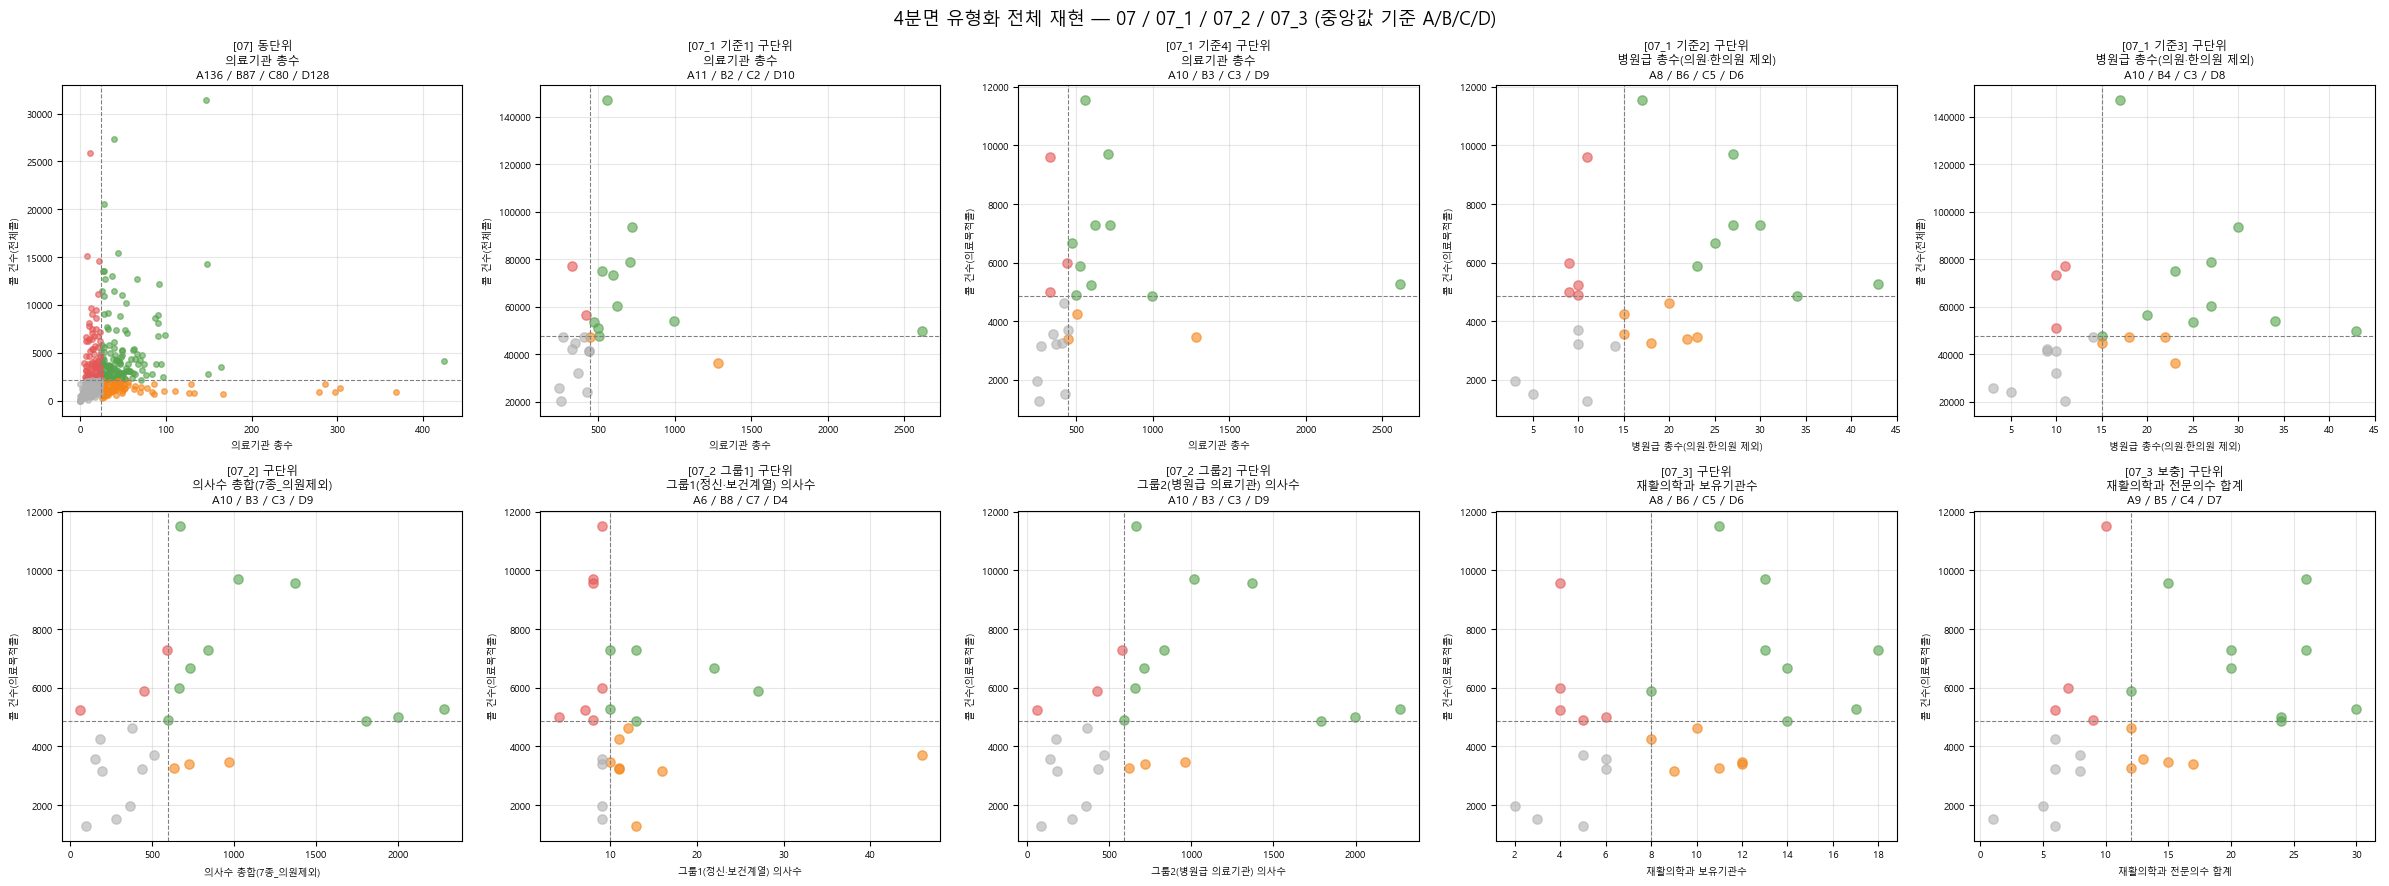

In [5]:
QUAD_COLOR = {"A": "#54a24b", "B": "#f58518", "C": "#e45756", "D": "#b0b0b0"}

fig, axes = plt.subplots(2, 5, figsize=(24, 9))
for ax, s in zip(axes.flat, SCHEMES):
    df = s["classified"]
    for label, sub in df.groupby("유형"):
        ax.scatter(sub[s["xcol"]], sub["콜건수"], s=16 if s["region"] == "동" else 45,
                   alpha=0.6, color=QUAD_COLOR[label])
    ax.axvline(s["med_x"], color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(s["med_y"], color="gray", linestyle="--", linewidth=0.8)
    counts = df["유형"].value_counts().reindex(["A", "B", "C", "D"], fill_value=0)
    count_str = " / ".join(f"{k}{v}" for k, v in counts.items())
    ax.set_title(f"[{s['source']}] {s['region']}단위\n{s['x_label']}\n{count_str}", fontsize=8.5)
    ax.set_xlabel(s["x_label"], fontsize=7)
    ax.set_ylabel(s["y_label"], fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)

fig.suptitle("4분면 유형화 전체 재현 — 07 / 07_1 / 07_2 / 07_3 (중앙값 기준 A/B/C/D)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. 구별 유형 종합 비교표 — 구 단위 9개 기준을 한 표로

동 단위(#1)는 구 단위표와 분석단위가 달라 6절에서 별도로 다룬다.

In [6]:
gu_schemes = [s for s in SCHEMES if s["region"] == "구"]

matrix = gu_schemes[0]["classified"][["목적구"]].copy()
for s in gu_schemes:
    col_name = f"[{s['source']}]"
    matrix[col_name] = s["classified"].set_index("목적구").loc[matrix["목적구"], "유형"].values

scheme_cols = [f"[{s['source']}]" for s in gu_schemes]
matrix["C형_횟수"] = (matrix[scheme_cols] == "C").sum(axis=1)
matrix["A형_횟수"] = (matrix[scheme_cols] == "A").sum(axis=1)
matrix["등장유형_종류수"] = matrix[scheme_cols].nunique(axis=1)

matrix = matrix.sort_values("C형_횟수", ascending=False).reset_index(drop=True)
display(matrix)

print(f"\n[참고] 9개 기준 각각에서 25개 구가 몇 번 C형(규모少+콜多, 확충 후보)으로 분류됐는지 집계했다.")
print("등장유형_종류수가 클수록(최대 4) 기준에 따라 유형이 크게 흔들리는 구라는 뜻이다.")

,목적구,[07_1 기준1],[07_1 기준4],[07_1 기준2],[07_1 기준3],[07_2],[07_2 그룹1],[07_2 그룹2],[07_3],[07_3 보충],C형_횟수,A형_횟수,등장유형_종류수
0,마포구,A,A,C,C,C,C,C,C,C,7,2,2
1,서대문구,C,C,C,C,A,C,A,C,A,6,3,2
2,동작구,D,C,C,D,A,C,A,C,C,5,2,3
3,양천구,A,A,C,C,A,C,A,C,C,5,4,2
4,종로구,D,C,C,D,A,C,A,C,A,4,3,3
5,노원구,A,A,A,A,A,C,A,A,C,2,7,2
6,강서구,A,A,A,A,C,A,C,A,A,2,7,2
7,은평구,A,A,A,A,C,A,C,A,A,2,7,2
8,강동구,A,A,A,A,A,C,A,A,A,1,8,2
9,중랑구,C,D,B,A,D,B,D,B,B,1,1,4



[참고] 9개 기준 각각에서 25개 구가 몇 번 C형(규모少+콜多, 확충 후보)으로 분류됐는지 집계했다.
등장유형_종류수가 클수록(최대 4) 기준에 따라 유형이 크게 흔들리는 구라는 뜻이다.


## 5. 로버스트니스(일관성) 확인

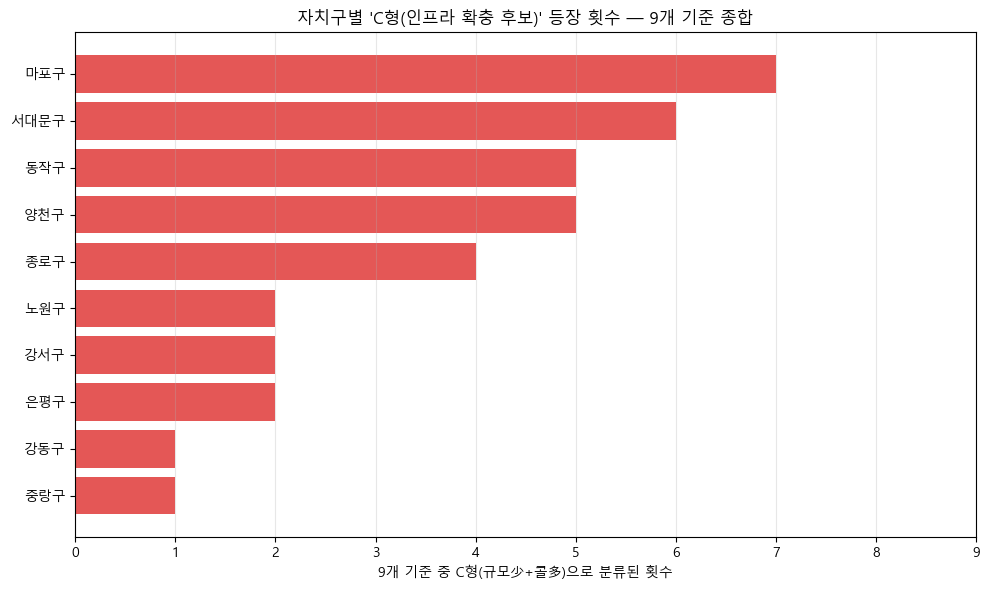

9개 기준 전부에서 유형이 동일하게 나온 구(가장 안정적): 7개
기준에 따라 유형이 가장 많이 바뀌는(등장유형 종류수=4) 구: ['중랑구']


In [7]:
top_c = matrix[matrix["C형_횟수"] > 0].sort_values("C형_횟수", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(top_c["목적구"][::-1], top_c["C형_횟수"][::-1], color="#e45756")
plt.xlabel("9개 기준 중 C형(규모少+콜多)으로 분류된 횟수")
plt.title("자치구별 'C형(인프라 확충 후보)' 등장 횟수 — 9개 기준 종합")
plt.xticks(range(0, 10))
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

n_consistent = (matrix["등장유형_종류수"] == 1).sum()
n_max_unstable = (matrix["등장유형_종류수"] == matrix["등장유형_종류수"].max()).sum()
print(f"9개 기준 전부에서 유형이 동일하게 나온 구(가장 안정적): {n_consistent}개")
print(f"기준에 따라 유형이 가장 많이 바뀌는(등장유형 종류수={matrix['등장유형_종류수'].max()}) 구: "
      f"{matrix.loc[matrix['등장유형_종류수'] == matrix['등장유형_종류수'].max(), '목적구'].tolist()}")

## 6. 동 단위 참고 (07 원본)

구 단위와 분석단위가 달라 4절 비교표에는 포함하지 않았다. 07 원본 결과를 그대로 재현만 한다.

In [8]:
dong_scheme = SCHEMES[0]
dong_result = dong_scheme["classified"]
print(dong_result["유형"].value_counts())

print("\n[참고] C형(의료少+콜多) 상위 10개 동")
display(
    dong_result[dong_result["유형"] == "C"]
    .sort_values("콜건수", ascending=False)
    .head(10)[["목적구", "행정동", "콜건수", "의료기관_총수"]]
)

유형
A    136
D    128
B     87
C     80
Name: count, dtype: int64

[참고] C형(의료少+콜多) 상위 10개 동


,목적구,행정동,콜건수,의료기관_총수
151,노원구,하계1동,25892,11
384,종로구,이화동,15126,8
195,동작구,신대방2동,14564,22
362,은평구,구산동,11126,21
154,도봉구,도봉2동,9638,12
79,관악구,보라매동,9495,18
30,강동구,상일1동,9019,13
27,강동구,둔촌2동,8612,18
145,노원구,월계2동,8145,10
223,서대문구,홍은2동,7788,10


## 종합 정리

**이 노트북에서 새로 확인된 것은 없다** — 07~07_3에서 각각 만든 4분면 유형화를 한곳에 모아 재현하고,
구 단위 9개 기준을 하나의 비교표(4절)로 합쳤을 뿐이다. 유일한 신규 산출물은 4절의 "C형_횟수" 종합 집계다.

**참고할 점**
- 마포구·서대문구·양천구는 여러 기준에서 반복적으로 C형(규모少+콜多)으로 나타난다 — 위 4·5절 표에서 직접 확인할 것.
- 다만 5절에서 보듯 **9개 기준 전부에서 동일하게 나오는 구는 일부에 그친다** — 기준(지표)에 따라 유형이
  바뀌는 구가 상당수 있으므로, 단일 기준만으로 "이 구는 인프라가 부족하다"고 단정하지 않는다.
- 상세 해석·통계 검정(Spearman rho, p-value 등)은 이 노트북에 없다 — 각 기준의 상세 근거는 원본 노트북
  (07/07_1/07_2/07_3)의 해당 절을 참고한다.
- 인구/장애인구 대비 정규화 미실시, 상관≠인과, 구 단위(n=25) 표본 작음 — 원본 노트북들의 한계가
  그대로 적용된다.